Epoch 0: Loss = 630660224.000000
Epoch 500: Loss = 516.979004
Epoch 1000: Loss = 362.250305
Epoch 1500: Loss = 244.416367
Epoch 2000: Loss = 164.686890
Epoch 2500: Loss = 112.040451

Comparison Table:
 Input Data Point (x)  Analytical Solution  ANN Solution  Point-wise Error
                  0.0             1.000000      1.000000          0.000000
                  0.5             0.960769      0.939705          0.021064
                  1.0             0.866025      0.741427          0.124599
                  1.5             0.755929      0.434487          0.321442
                  2.0             0.654654      0.076214          0.578439
                  2.5             0.569495     -0.293617          0.863111
                  3.0             0.500000     -0.656700          1.156700
                  3.5             0.443533     -1.008450          1.451982
                  4.0             0.397360     -1.352341          1.749701
                  4.5             0.359211     -1

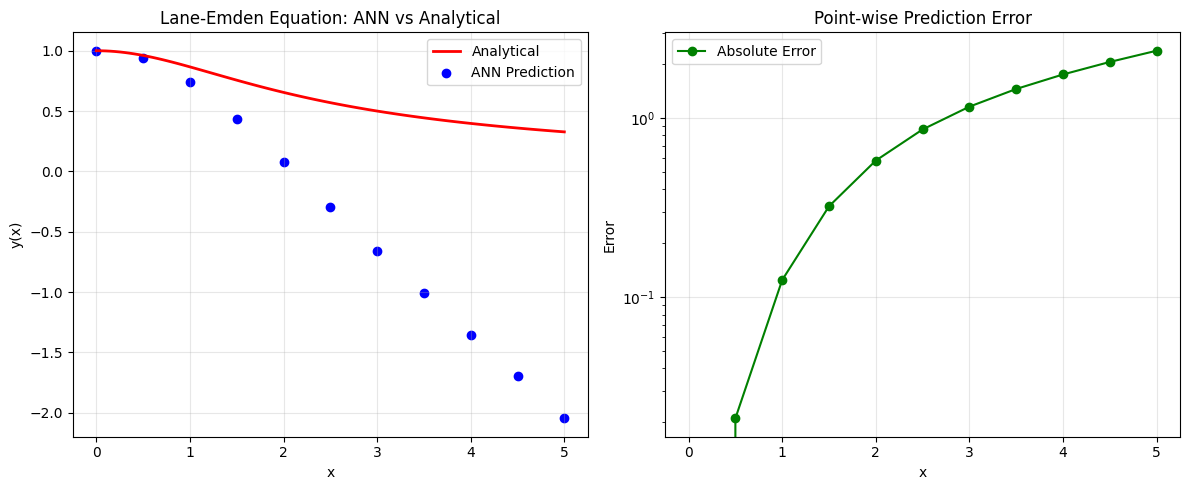

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Define the Neural Network Architecture
class ODE_Net(nn.Module):
    def __init__(self):
        super(ODE_Net, self).__init__()
        # Simple feed-forward network: 1 input -> 20 hidden -> 20 hidden -> 1 output
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# 2. Define the trial solution to satisfy Initial Conditions (IC)
# y(0) = 1 and y'(0) = 0
# We use: y_trial = 1 + (x^2 * ANN(x))
def trial_solution(x, net):
    return 1 + (x**2) * net(x)

# 3. Training Logic
def train_pinn(epochs=2000):
    net = ODE_Net()
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

    # Points to evaluate the ODE (x >= 0)
    x_train = torch.linspace(0, 5, 100).view(-1, 1).requires_grad_(True)

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Calculate y and its derivatives using autograd
        y = trial_solution(x_train, net)

        dy_dx = torch.autograd.grad(y, x_train, torch.ones_like(y), create_graph=True)[0]
        d2y_dx2 = torch.autograd.grad(dy_dx, x_train, torch.ones_like(dy_dx), create_graph=True)[0]

        # The ODE: y'' + (2/x)y' + y^5 = 0
        # To avoid division by zero at x=0, we use a small epsilon or limit logic
        # For Lane-Emden, as x->0, (2/x)y' -> 0 because y'(0)=0.
        eps = 1e-7
        ode_residual = d2y_dx2 + (2 / (x_train + eps)) * dy_dx + y**5

        loss = torch.mean(ode_residual**2)

        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

    return net

# 4. Analytical Solution for comparison
def analytical_sol(x):
    return (1 + (x**2)/3)**(-0.5)

# --- Execution and Visualization ---

# Train the model
model = train_pinn(3000)

# Generate test points
x_test = torch.linspace(0, 5, 11).view(-1, 1) # 11 points for the table
y_ann = trial_solution(x_test, model).detach().numpy().flatten()
x_test_np = x_test.numpy().flatten()
y_exact = analytical_sol(x_test_np)
error = np.abs(y_exact - y_ann)

# Create Table
data = {
    "Input Data Point (x)": x_test_np,
    "Analytical Solution": y_exact,
    "ANN Solution": y_ann,
    "Point-wise Error": error
}
df = pd.DataFrame(data)
print("\nComparison Table:")
print(df.to_string(index=False))

# Plotting Results
plt.figure(figsize=(12, 5))

# Plot 1: Solution Comparison
plt.subplot(1, 2, 1)
x_dense = np.linspace(0, 5, 100)
plt.plot(x_dense, analytical_sol(x_dense), 'r-', label='Analytical', linewidth=2)
plt.scatter(x_test_np, y_ann, color='blue', label='ANN Prediction', marker='o')
plt.title("Lane-Emden Equation: ANN vs Analytical")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Error
plt.subplot(1, 2, 2)
plt.plot(x_test_np, error, 'g-o', label='Absolute Error')
plt.title("Point-wise Prediction Error")
plt.xlabel("x")
plt.ylabel("Error")
plt.yscale('log') # Log scale to see small errors clearly
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()